In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

df_user = pd.read_csv("../dataset/user_twitter_data.csv")



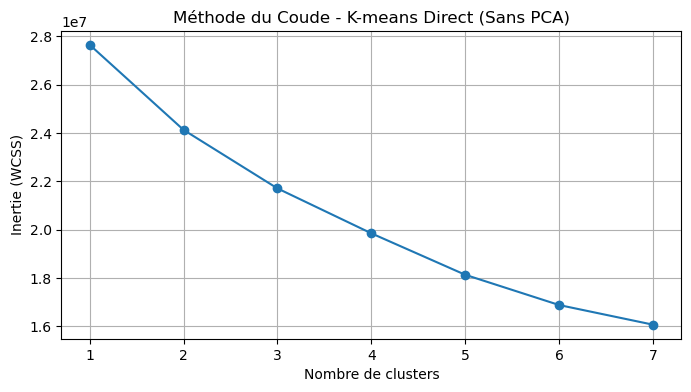

In [2]:
# Pour éviter que les comptes à millions de followers n'écrasent le K-means,
# on applique une transformation logarithmique sur les compteurs bruts.
df_user = pd.read_csv("../dataset/user_twitter_data.csv")

# Liste des variables numériques 
features = [
    "followers_count", "friends_count", "statuses_count", "favourites_count",
    "listed_count", "retweet_count", "favorite_count", "reply_count", "quote_count",
    "hashtags_count", "urls_count", "mentions_count", "tweet_length",
    "is_retweet", "is_quote", "n_tweets", "followers_friends_ratio",
    "activity_ratio", "visibility_score"
]

#On isole les features à utiliser
X = df_user[features].copy()

for col in ["followers_count", "friends_count", "statuses_count", "favourites_count"]:
    X[col] = np.log1p(X[col])

# Le K-means calcule des distances. Il faut donc centrer-réduire
# pour qu'une variable à 10 000 n'écrase pas une proportion entre 0 et 1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Recherche du K optimal
# La méthode du coude
# On crée une boucle qui va tester successivement l'algorithme en lui demandant de créer 1 cluster, puis 2, puis 3...
# On va tester les clusters pour voir où se trouve la "cassure"
wcss = []
for i in range(1, 8):
    kmeans_test = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans_test.fit(X_scaled) # Calcul direct sur les 19 dimensions normalisées
    wcss.append(kmeans_test.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 8), wcss, marker='o')
plt.title("Méthode du Coude - K-means Direct (Sans PCA)")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie (WCSS)")
plt.grid(True)
plt.show()



In [9]:
# L'algorithme doit calculer les distances pour plus de 1,8 million de lignes, mais cette fois sur 19 colonnes en même temps. 
#Mathématiquement, le nombre d'opérations géométriques à effectuer par le processeur a été multiplié par un facteur énorme.

k_sans_pca = 6

kmeans_direct = KMeans(n_clusters=k_sans_pca, init='k-means++', random_state=42, n_init=10)
df_user['cluster_direct'] = kmeans_direct.fit_predict(X_scaled)

# On calcule le portrait-robot de ces nouveaux clusters
tableau_profils_direct = df_user.groupby('cluster_direct')[features].mean()
tableau_profils_direct['nb_comptes'] = df_user.groupby('cluster_direct').size()

print("--- CARACTÉRISTIQUES MOYENNES (K-MEANS SANS PCA) ---")
print(tableau_profils_direct.round(2))

--- CARACTÉRISTIQUES MOYENNES (K-MEANS SANS PCA) ---
                followers_count  friends_count  statuses_count  \
cluster_direct                                                   
0                       8221.35        1048.92        14517.46   
1                         81.29         147.90          879.00   
2                       1568.36         635.14        20423.20   
3                   12238769.26        8923.99       147790.50   
4                       2704.56        1168.45        24531.40   
5                   13821728.78           1.20        60306.85   

                favourites_count  listed_count  retweet_count  favorite_count  \
cluster_direct                                                                  
0                        5945.19         49.13            0.0             0.0   
1                         579.75          0.83            0.0             0.0   
2                       11646.35         14.68            0.0             0.0   
3            

Sans le PCA, il faut plus de ressources pour faire tourner le Kmeans mais on obtient un résultat plus détaillé


Cluster 0 : Les "Créateurs de Contenu Engagés" (Humains influents à leur échelle)
- Qui ils sont : Un groupe de 332 382 comptes.
- Leur comportement : Ils ont une jolie communauté locale (~8 200 followers), ne retweetent presque jamais (is_retweet = 0.07, soit seulement 7% de RT),
  écrivent des tweets personnels courts (tweet_length = 89.5), utilisent des hashtags (1.73) 
  et écrivent pas mal de tweets originaux ($n\_tweets = 3.82$).
- Interprétation : Ce sont des comptes d'humains passionnés de foot ou des micro-influenceurs. 
  Ils n'utilisent pas Twitter pour relayer passivement le flux, mais pour donner leur avis en direct, 
  débattre et créer de vraies discussions sur la Coupe du Monde.

Cluster 1 : Les "Comptes Jeunes / Nouveaux Spectateurs"
- Qui ils sont : Un gros bloc de 341 063 comptes.
- Leur comportement : Ce sont de tout petits comptes très récents ou très discrets : ils ont très peu d'abonnés (81 followers en moyenne) 
  et un historique d'activité très faible (statuses_count = 879). Ils relaient massivement les autres (is_retweet = 0.82) 
  avec des tweets assez longs (119 caractères) contenant des mentions (1.06).
- Interprétation : Ce sont des utilisateurs occasionnels, de nouveaux inscrits venus sur Twitter spécialement pour suivre l'événement mondial, 
  ou des comptes "fantômes" qui se contentent d'interpeller des gens ou de relayer les actualités sans rien produire eux-mêmes.
  
Cluster 2 : Les "Spammeurs de Liens / Agrégateurs de Médias" (Profil Atypique 1)
- Qui ils sont : Un groupe de 304 737 comptes.
- Leur comportement : Ils ont un gros taux de partage de liens externes : urls_count = 0.96 (soit presque 1 lien systématique par tweet) 
  et n'utilisent presque pas de hashtags (0.21). 
  Ils ont la particularité de faire énormément de citations de tweets (is_quote = 0.94, soit 94% de citations).
- Interprétation : Ce profil est très suspect et s'apparente à des bots ou des comptes d'automatisation. 
  Ils passent leur temps à citer les tweets des autres pour y greffer un lien (liens de streaming illégaux, site de paris sportifs, revente de billets).

Cluster 3 : Les "Super-Diffuseurs / Professionnels de l'Information" (Profil Atypique 2)
- Qui ils sont : Une micro-élite de seulement 81 comptes.
- Leur comportement : Ils possèdent une audience immense (12,2 millions de followers), un historique monstrueux (statuses_count = 147 790) 
  et ce sont les plus gros bombardeurs du dataset : ils ont publié en moyenne 14.57 tweets chacun pendant la période, 
  bourrés de hashtags (1.46) et de liens d'actualité (0.58).
- Interprétation : Ce sont les grands médias sportifs internationaux (L'Équipe, Sky Sports, ESPN), les journalistes officiels
  ou les comptes officiels des sélections nationales. Ils font du "live-texte" non-stop.

Cluster 4 : Les "Amplificateurs de Masse" (Le cœur du réseau)
- Qui ils sont : Le plus gros groupe du dataset de très loin (865 171 comptes).
- Leur comportement : Ils ont environ 2 700 followers, un historique de tweets moyen (~24 500) 
  et un comportement d'automatisation ou de relai passif absolu : is_retweet = 0.97 (97% de leur activité consiste à cliquer sur le bouton Retweet). 
  Ils utilisent beaucoup de mentions (1.21).
- Interprétation : C'est l'armée de l'ombre de Twitter. Ce sont les fans de foot lambdas qui agissent comme une caisse de résonance géante. 
  Dès qu'un but est marqué ou qu'une star tweete, ce groupe relaie instantanément l'information, faisant grimper les tendances de la Coupe du Monde.
  
Cluster 5 : Les "Stars Absolues / Icônes Intouchables" (Profil Atypique 3)
- Qui ils sont : Un groupe ultra-exclusif de seulement 5 comptes.
- Leur comportement : Ils affichent les statistiques les plus extrêmes du projet. 
  Ils ont en moyenne 13,8 millions de followers mais un ratio social unique : 
  ils ne suivent quasiment personne (friends_count = 1.20 abonnement en moyenne). 
  Ils écrivent très peu ($n\_tweets = 2$), ne font jamais de citations (is_quote = 0) 
  et affichent le visibility_score le plus élevé du dataset (13,9 millions).
- Interprétation : Ce sont les superstars planétaires de la Coupe du Monde (les comptes officiels de Cristiano Ronaldo, Lionel Messi, Neymar, 
  Kylian Mbappé ou le compte principal de la FIFA). 
  Ils ne s'abonnent à personne, tweetent rarement, mais chacun de leurs mots secoue le réseau.
  

Détection fine des anomalies : le Cluster 2 permet d'identifier des comptes potentiellement automatisés ou assimilables à des bots, caractérisés par un taux de citation de tweets de 94 % et près d'un lien externe par publication.
